## Exploratory Data Analysis

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_parquet("base_consolidada_logistica.parquet")

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   customer_id                    112650 non-null  str           
 2   order_status                   112650 non-null  str           
 3   order_purchase_timestamp       112650 non-null  datetime64[us]
 4   order_approved_at              112635 non-null  str           
 5   order_delivered_carrier_date   111456 non-null  str           
 6   order_delivered_customer_date  110196 non-null  datetime64[us]
 7   order_estimated_delivery_date  112650 non-null  datetime64[us]
 8   order_item_id                  112650 non-null  int64         
 9   product_id                     112650 non-null  str           
 10  seller_id                      112650 non-null  str           
 11  shipping_li

In [4]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,shipping_limit_date,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_comment_message,review_score,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,2017-10-06 11:07:15,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,"Não testei o produto ainda, mas ele veio corre...",4.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,2018-07-30 03:24:27,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,Muito bom o produto.,4.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,2018-08-13 08:55:23,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,NaN,5.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,2017-11-23 19:45:59,45.00,27.20,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,O produto foi exatamente o que eu esperava e e...,5.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,...,2018-02-19 20:31:37,19.90,8.72,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,NaN,5.0,0


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,112650,98666,fc3d1daec319d62d49bfb5e1f83123e9,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,112650,7,delivered,110197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,112650,NaN,NaN,NaN,2018-01-01 00:09:48.464376,2016-09-04 21:15:19,2017-09-13 19:17:04,2018-01-19 23:02:16,2018-05-04 17:30:36.750000,2018-09-03 09:06:57,NaN
order_approved_at,112635,90174,2018-02-24 03:20:27,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_carrier_date,111456,81017,2018-05-09 15:48:00,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_customer_date,110196,NaN,NaN,NaN,2018-01-14 13:25:24.023939,2016-10-11 13:46:32,2017-09-26 20:09:44.500000,2018-02-02 20:57:23,2018-05-15 20:09:21.500000,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,112650,NaN,NaN,NaN,2018-01-24 20:12:15.531291,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
order_item_id,112650.0,NaN,NaN,NaN,1.197834,1.0,1.0,1.0,1.0,21.0,0.705124
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Getting an idea of how much are the late orders.
df["is_late"].value_counts(dropna=False, normalize=True) 

is_late
0       0.900852
1       0.077364
<NA>    0.021784
Name: proportion, dtype: Float64

In [12]:
#Analysing Nulls
nulls = df.isna().mean().sort_values(ascending=False)
nulls[nulls > 0].head(30)

review_comment_message           0.579139
order_delivered_customer_date    0.021784
is_late                          0.021784
order_delivered_carrier_date     0.010599
review_score                     0.008362
order_approved_at                0.000133
dtype: float64

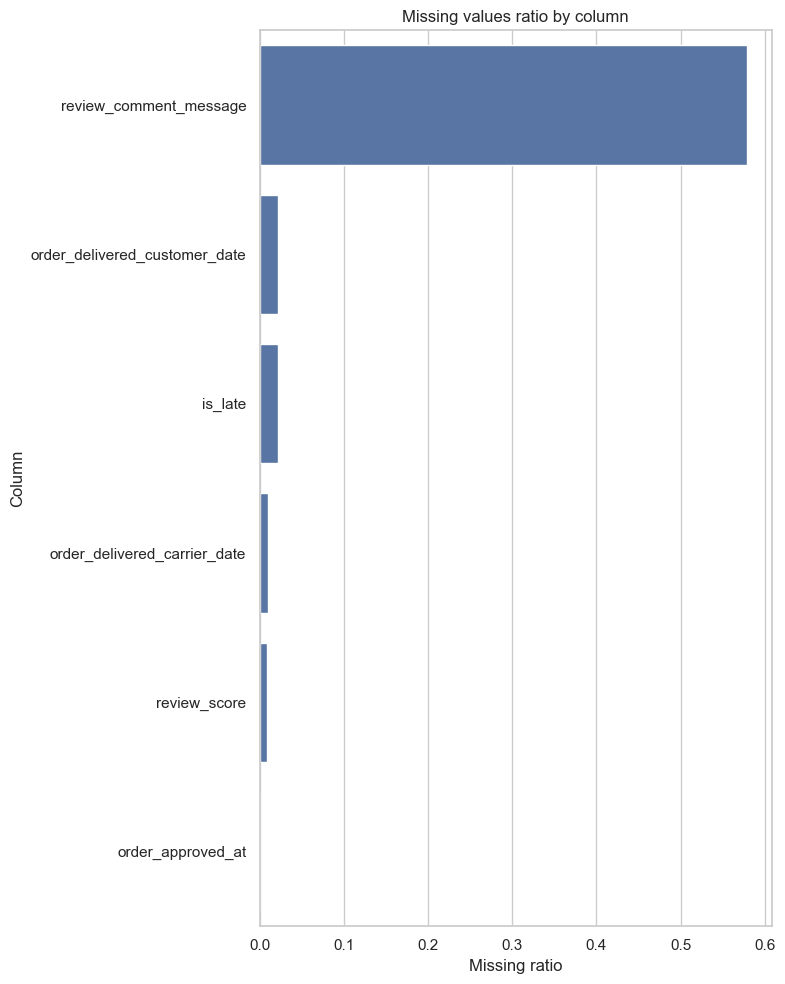

In [18]:
# Plot null ratios
plt.figure(figsize=(8, 10))
sns.barplot(x=nulls[nulls > 0], y=nulls[nulls > 0].index)
plt.title("Missing values ratio by column")
plt.xlabel("Missing ratio")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

### Missing values - main observations:

- Some columns have a non‑negligible proportion of missing values, especially date fields related to delivery and review text fields.
- Columns with missing values are mostly expected (e.g. orders not delivered or without reviews), so they are likely informative rather than random noise.
- There are no columns with an extremely high null ratio that would be immediate candidates for dropping at this stage.
- We will need to handle missing values carefully during feature engineering, possibly with separate indicators (flags) for “missing” where it makes business sense.

In [22]:
# Derive delivery time columns to enhance features

df["actual_delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

df["estimated_delivery_days"] = (
    df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
).dt.days

df["delay_vs_estimated_days"] = (
    df["actual_delivery_days"] - df["estimated_delivery_days"]
)

In [28]:
# Descriptive statistics for delivery times
df[["actual_delivery_days", "estimated_delivery_days", "delay_vs_estimated_days"]].describe()

,actual_delivery_days,estimated_delivery_days,delay_vs_estimated_days
count,110196.000000,112650.000000,110196.000000
mean,12.007723,23.470484,-11.433446
std,9.451455,8.884872,10.170284
min,0.000000,2.000000,-146.000000
25%,6.000000,18.000000,-17.000000
50%,10.000000,23.000000,-12.000000
75%,15.000000,28.000000,-7.000000
max,209.000000,155.000000,189.000000


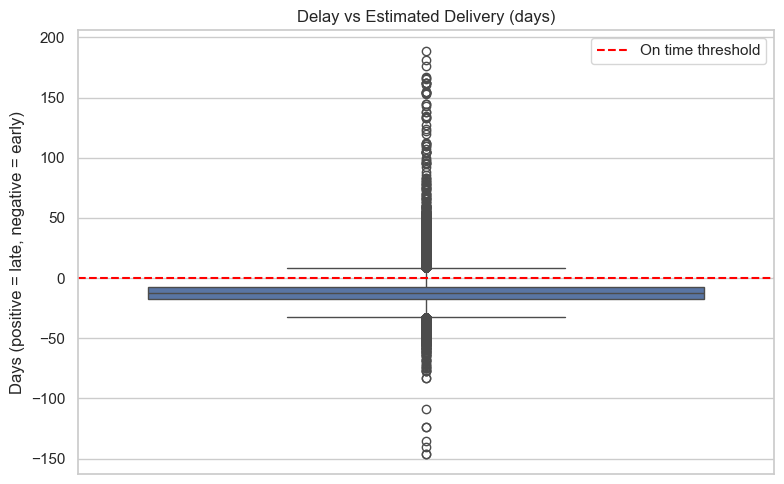

In [33]:
# Boxplot of delay vs estimated delivery days
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df[df["delay_vs_estimated_days"].notna()],
    y="delay_vs_estimated_days"
)
plt.axhline(0, color="red", linestyle="--", label="On time threshold")
plt.title("Delay vs Estimated Delivery (days)")
plt.ylabel("Days (positive = late, negative = early)")
plt.legend()
plt.tight_layout()
plt.show()

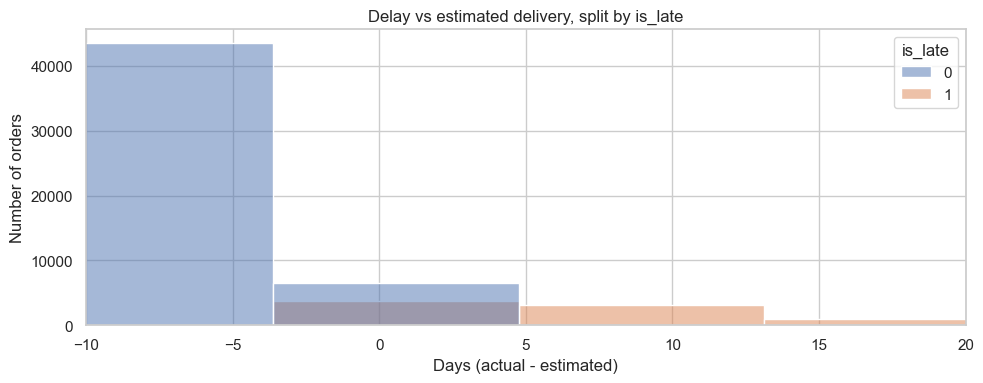

In [31]:
# Plot delay distribution split by is_late
plt.figure(figsize=(10, 4))
sns.histplot(
    data=df[df["is_late"].notna()],
    x="delay_vs_estimated_days",
    hue="is_late",
    bins=40,
    kde=False,
    multiple="layer"
)
plt.xlim(-10, 20)
plt.title("Delay vs estimated delivery, split by is_late")
plt.xlabel("Days (actual - estimated)")
plt.ylabel("Number of orders")
plt.tight_layout()
plt.show()

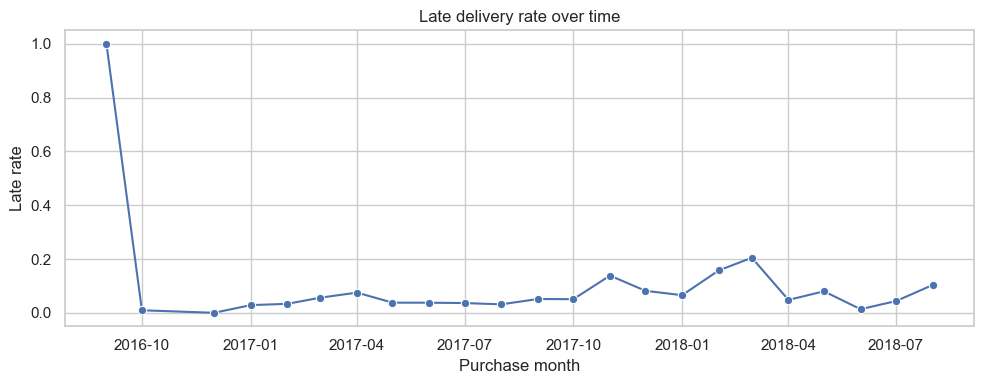

In [35]:
# Aggregate late rate by purchase month
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M")

monthly = (
    df[df["is_late"].notna()]
    .groupby("purchase_month")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", lambda x: (x == 1).sum()),
        ontime_orders=("is_late", lambda x: (x == 0).sum())
    )
)

monthly["late_rate"] = monthly["late_orders"] / (
    monthly["late_orders"] + monthly["ontime_orders"]
)
monthly.index = monthly.index.to_timestamp()

# Plot monthly late rate
plt.figure(figsize=(10, 4))
sns.lineplot(data=monthly, x=monthly.index, y="late_rate", marker="o")
plt.title("Late delivery rate over time")
plt.xlabel("Purchase month")
plt.ylabel("Late rate")
plt.tight_layout()
plt.show()

### Dates and delivery times – main findings:

- The `delay_vs_estimated_days` variable shows that many orders are delivered slightly before or very close to the estimated date, but there is a noticeable right tail of late deliveries.
- The histogram of `delay_vs_estimated_days` indicates that small positive delays (a few days) are relatively common, while very large delays are less frequent but still present.
- The boxplot split by `is_late` shows a clear separation between on‑time and late orders: late orders have a much higher median delay and a wider spread, which validates `delay_vs_estimated_days` as a strong candidate feature for the model.
- There is a peak of delays in an specific period between the end of 2017 and the firs trimester of 2018.

In [38]:
# Aggregate late rate by customer state
state_late = (
    df[df["is_late"].notna()]
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", lambda x: (x == 1).sum())
    )
)

state_late["late_rate"] = state_late["late_orders"] / state_late["total_orders"]
state_late = state_late.sort_values("late_rate", ascending=False)

state_late

,total_orders,late_orders,late_rate
customer_state,,,
AL,397,103,0.259446
MA,717,163,0.227336
SE,335,61,0.18209
CE,1279,218,0.170446
PI,476,81,0.170168
BA,3256,504,0.154791
RJ,12353,1835,0.148547
TO,274,38,0.138686
PA,946,131,0.138478


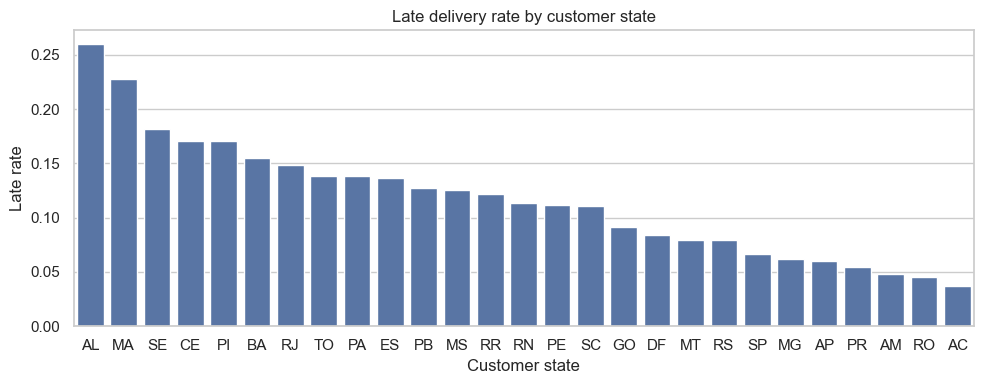

In [39]:
# Plot late rate by state
plt.figure(figsize=(10, 4))
sns.barplot(
    data=state_late.reset_index(),
    x="customer_state",
    y="late_rate",
    order=state_late.index
)
plt.title("Late delivery rate by customer state")
plt.xlabel("Customer state")
plt.ylabel("Late rate")
plt.tight_layout()
plt.show()